# Preprocessing and Analysis

This section prepares the data before feeding it into machine learning models.

## Required Libraries

This part includes the necessary Python libraries for data processing, machine learning, and visualization. 

In [1]:
# required libraries
import os
import math
import time
from pathlib import Path
import tempfile
import functools
import pandas as pd
import numpy as np
import geopandas as gpd
import statistics
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_error, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
pd.set_option("display.max_rows", None)
import scipy, joblib
import scipy.signal
import scipy.stats
from scipy import stats
from scipy.stats import pearsonr
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import confusion_matrix,  classification_report, roc_auc_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xg
from matplotlib.pyplot import figure
from matplotlib import pyplot
from IPython.display import display, clear_output
import logging
import keras
from keras.models import Sequential
import keras.backend as k
from keras.layers import Dense, GRU, LSTM, Activation, Masking, Dropout, BatchNormalization,Conv1D
from keras.callbacks import History
import keras.optimizers 
from keras import callbacks
#!pip install xgboost
from meteostat import Point, Daily, Hourly
from datetime import datetime, timedelta
import urllib
from urllib.error import HTTPError
import pickle
import requests
import folium
from folium.plugins import HeatMap, Draw, HeatMapWithTime
from tqdm.contrib.concurrent import process_map
from shapely.geometry import Point
import uuid
import pyarrow as pa
import pyarrow.parquet as pq
import shap
import warnings
warnings.filterwarnings('ignore')

2025-08-04 07:16:39.910865: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-04 07:16:40.271786: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-04 07:16:40.586910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754291800.829170   21843 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754291800.899231   21843 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-04 07:16:41.579324: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
cache_dir = "data"
cache_dir = Path(tempfile.gettempdir()) if cache_dir is None else Path(cache_dir)
        
# make cache dir
cache_dir.mkdir(exist_ok=True, parents=True)

## Loading Final Validation Data

In [31]:
table2 = pq.read_table('data/val_light_ecoliall51_weather.parquet')
datasetxx = table2.to_pandas()
datasetxx.shape

(17223, 66)

In [32]:
target_date = '2024-07-01'
# Filter the DataFrame to keep only rows on or after the target date
datasetxx = datasetxx[datasetxx['timedate'] >= target_date].reset_index(drop=True)
datasetxx.shape

(11994, 66)

## Add Season Feature

Generate season and time columns, and adds inland and coastal area seperation instead of distance to coast.

In [35]:
datasetxxt = datasetxx.drop(['Salinity', 'timedate', 'samplingPointnotation', 'station_type'], axis=1)

datasetxxt['season'] = pd.DatetimeIndex(datasetxxt['date']).month%12 // 3 + 1 # Season
datasetxxt['time'] = pd.DatetimeIndex(datasetxxt['time']).hour
# considers sampling location with less than 5km distance from coast as coastal and rest as inland sampling location
datasetxxt['distance_to_coast'] = datasetxxt['distance_to_coast'].apply(lambda x: 0 if x<=5000 else 1)
#datasetxxt = datasetxxt.dropna().reset_index(drop=True)
datasetxxt.shape
#a = np.array(datasetxxt['E.coli C-MF'].values)
#datasetxxt['E.coli C-MF'] = np.where(a > 10000, 10000, a) # replace values with higher than 10k with 10k (can be deleted based on need)

(11994, 63)

In [36]:
datasetxxt.columns

Index(['Lat', 'Long', 'date', 'time', 'Ecoli', 'land_cover', 'agri', 'forest',
       'grass', 'wetland', 'build', 'others', 'lst', 'fpar', 'emis31', 'lai',
       'temperature_11am', 'humidity_11am', 'windspeed_11am', 'windgusts_11am',
       'winddirection_11am', 'precipitation_11am', 'rain_11am',
       'snowfall_11am', 'cloudcover_11am', 'pressure_msl_11am',
       'soil_temp_7cm', 'soil_moist_7cm', 'vap_press_def', 'et0_fao_evap',
       'sun_duration', 'global_tilted_irr', 'short_rad', 'dir_rad',
       'dew_point_2m', 'temp_min', 'temp_max', 'precipitation_sum', 'rain_sum',
       'snowfall_sum', 'windspeed_max', 'windgusts_max',
       'winddirection_dominant', 'precipitation_hours', 'sunshine_duration_d',
       'daylight_duration_d', 'short_rad_sum_d', 'et0_fao_evap_d', 'temp_min7',
       'temp_max7', 'precipitation_sum7', 'rain_sum7', 'snowfall_sum7',
       'windspeed_max7', 'windgusts_max7', 'winddirection_dominant7',
       'precipitation_hours7', 'sunshine_duration_d7',

## Data Split

In [37]:
#datasetxxt['E.coli C-MF'] = np.log10(datasetxxt['E.coli C-MF'])
y_test = datasetxxt['Ecoli']
X_test = datasetxxt.drop(['Ecoli','Lat', 'Long', 'date'], axis=1)

In [38]:
X_test.shape

(11994, 59)

### Show Validation sampling locations on the map 

In [8]:
# Show test and train locations on the map for Geographical Split
import folium
import pandas as pd
import branca.colormap as cm
from scipy import stats
from utils import getradius1

grouped_data = datasetxxt[['Ecoli','Long','Lat']]
grouped_data = grouped_data.dropna().reset_index(drop=True)
grouped_data = grouped_data.groupby(["Lat", "Long"]).agg(
    ecoli_mean = ("Ecoli","mean"),
    ecoli_count = ("Ecoli","count")
).reset_index()

# Sample data generation (Replace this with your actual DataFrame)
df = grouped_data
df = df[df['Lat'] > 49.90] #Drop unwanted rows
df = df[df['Lat'] < 61] #Drop unwanted rows


m = folium.Map(location=[df['Lat'].median(), df['Long'].median()], zoom_start=5)

colormap = cm.LinearColormap(colors=['green', 'yellow'], vmin=0, vmax=1000000000)

# Add circle markers for each location
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius= getradius1(row['ecoli_count']*100),  # Scale the radius according to the counts
        color=colormap(row['ecoli_mean']),  # Assign color based on intensity
        fill=True,
        fill_opacity=0.6,
        popup=f"Intensity: {row['ecoli_mean']}"
    ).add_to(m)

# Save map to an HTML file
#m.save('ecoli_v.html')

m

## Distribution Analysis

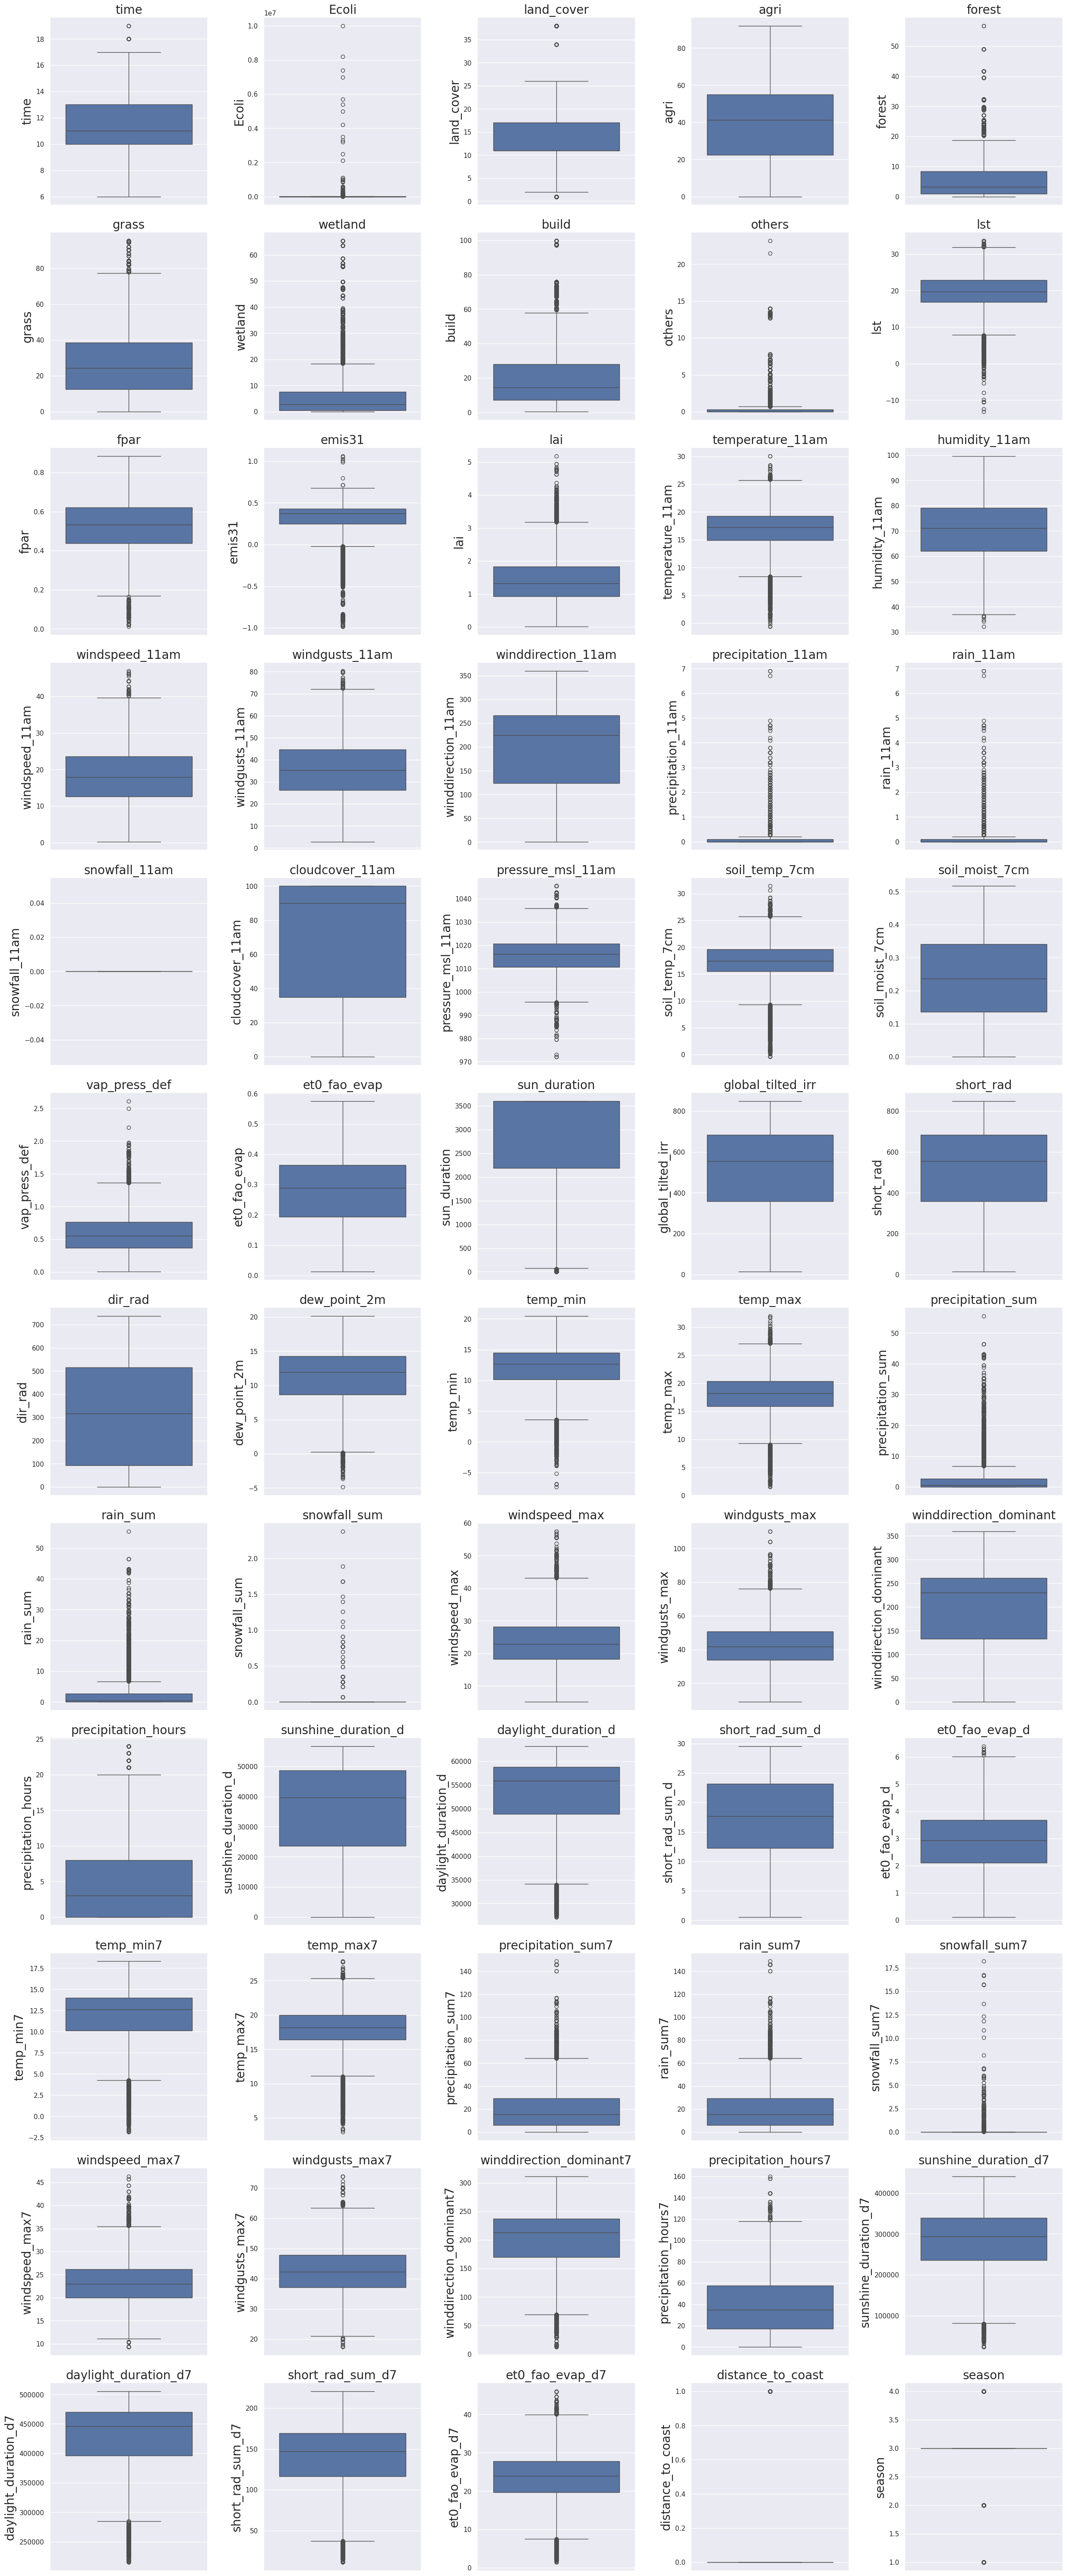

In [9]:
# distribution analysis
def plot_boxplots(df):
    i = 5
    num_columns = len(df.columns)
    num_rows = math.ceil(num_columns/i)
    
    fig, axes = plt.subplots(nrows=num_rows, ncols=min(i,num_columns), figsize=(5*min(i,num_columns), 5*num_rows))
    
    plt.rcParams['font.size'] = '16'
    axes = axes.flatten()
    if num_columns == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        sns.boxplot(data=df, y=col, ax=axes[i])
        axes[i].set_title(f'{col}' , fontsize=20)
        axes[i].set_ylabel(col, fontsize=20)
    
    for i in range(num_columns, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

plot_boxplots(datasetxxt.drop(['Lat', 'Long', 'date'], axis=1))

## Normalization

The saved Normalization scales are loaded to be used in the inference phase.

In [8]:
# Choose between Scaler_Tmp_adv.save and Scaler_Geo_adv.save depending on model trained approach
Scaler = joblib.load("Model/Scaler_Tmp_lgt.save")
X_testN = Scaler.transform(X_test)

## XGBRegressor E.coli Estimator

In [84]:
#X_test = pd.read_csv('data/Xtest.csv')
#y_test = pd.read_csv('data/ytest.csv')

In [9]:
#load model
# Choose between xgbr_f{fold}_Tmp_lgt.joblib and xgbr_f{fold}_Geo_lgt.joblib depending on model trained approach
trained_models = [joblib.load(f'Model/xgbr_f{fold}_Tmp_lgt.joblib') for fold in range(10)]

preds = []
test_dmatrix = xg.DMatrix(data = X_test, label = y_test) 
for model in trained_models:
    preds.append(pd.Series(data=model.predict(test_dmatrix), dtype='float64'))
preds = pd.concat(preds, axis=1)
preds = preds.mean(axis=1)
preds[preds<0] = 0 # replace negative prediction with zero

# to calculate RMSE we need to also down scale the test samples as well
a = np.array(y_test.values)
y_test1 = np.where(a > 10000, 10000, a) 

# RMSE Computation 
print('Test RMSE:{}'.format(np.sqrt(mean_squared_error(y_test1,preds))))

Test RMSE:2092.3955008693433


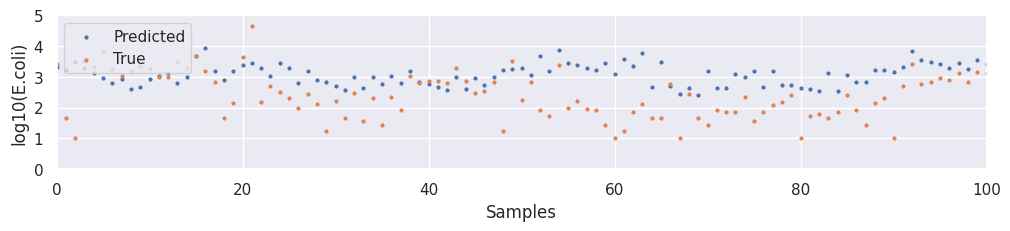

In [10]:
plt.figure(figsize=(12,2))
plt.scatter(preds.index,np.log10(preds.to_numpy()), label='Predicted', s=4)
plt.scatter(preds.index,np.log10(y_test.to_numpy()),label="True", s=4)            
plt.ylabel("log10(E.coli)")
plt.xlabel("Samples")
plt.legend(loc='upper left')
plt.ylim(0,5)
plt.xlim(0,100)
plt.show()

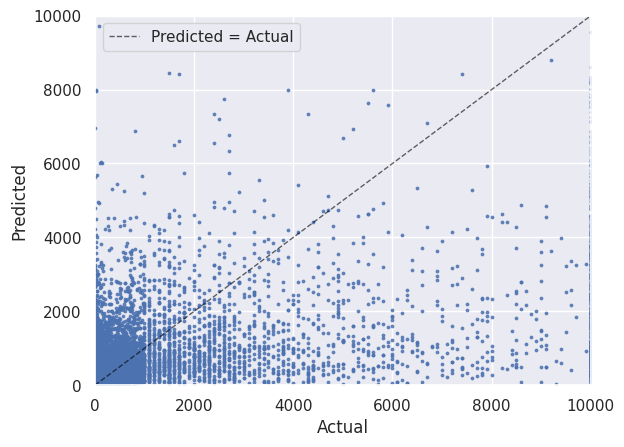

In [11]:
plt.scatter(x=y_test1, y=preds, s=3, alpha=0.8)
plt.axline((0, 0),(10000, 10000),color="black",linestyle="--",alpha=0.6,linewidth=1,label="Predicted = Actual",)
plt.xlim(0, 10000)
plt.ylim(0, 10000)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

### Three classes confusion matrix

col_0,low,moderate,high
row_0,,,
high,0.056575,0.260225,0.550958
moderate,0.340351,0.564417,0.377613
low,0.603074,0.175358,0.071429


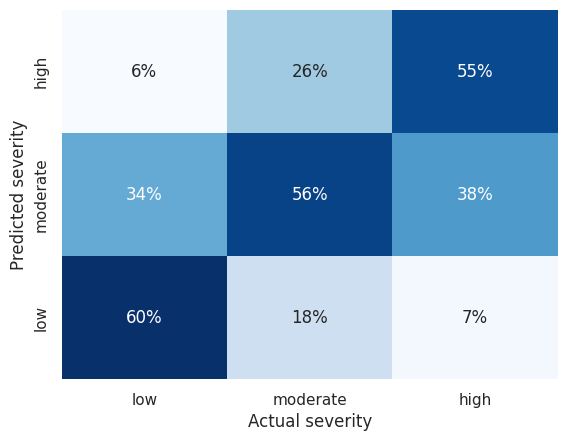

In [13]:
# three classes (x<235, 235<x<1000, 1000<x)
yt_severity = y_test.astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))
yp_severity = pd.DataFrame({'ecoli': preds})['ecoli'].astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low": 1, "moderate": 2, "high": 3}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"

normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")
to_plot

### Two classes confusion matrix

Performance accuracy: 0.77831
col_0         low-moderate  high
row_0                           
high                  1771  2427
low-moderate          6908   888


Text(46.24999999999999, 0.5, 'Predicted severity')

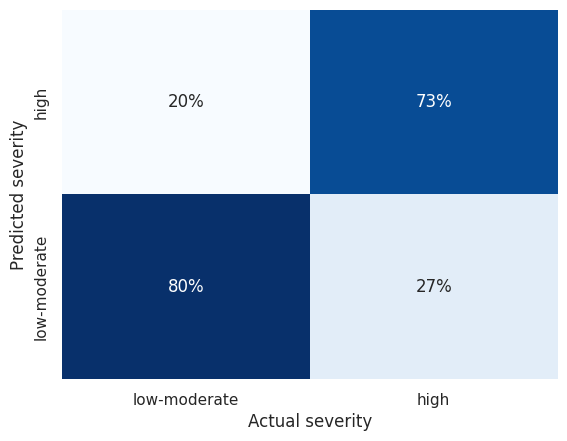

In [14]:
# two classes (x<thr, thr<x)
# U can change the threshold by choosing "thr" value
thr = 500
yt_severity = y_test.astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))
yp_severity = pd.DataFrame({'ecoli': preds})['ecoli'].astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low-moderate": 1, "high": 2}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"
Accuracy = ((to_plot['high']['high'] + to_plot['low-moderate']['low-moderate'])/y_test.size)
print("Performance accuracy: %.5f" % Accuracy)
print(to_plot)
normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")

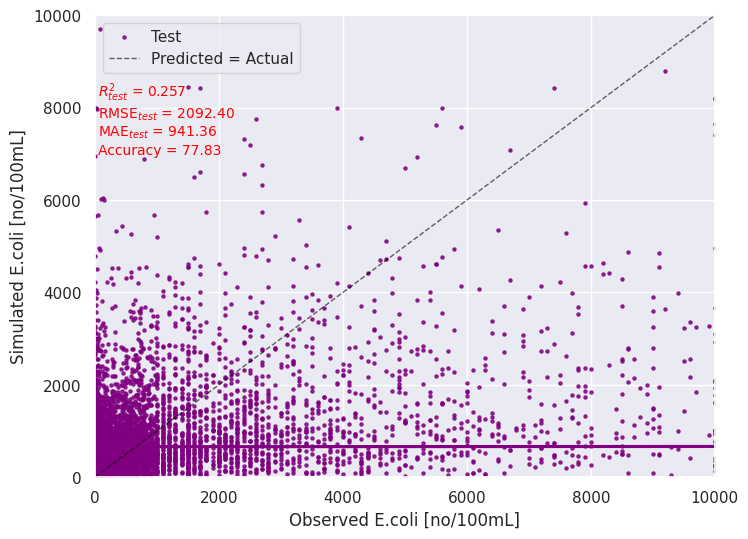

In [15]:
# Calculating metrics
r2_test = r2_score(y_test1, preds)
mae_test = mean_absolute_error(y_test1, preds)
rmse_test = np.sqrt(mean_squared_error(y_test1, preds))

# Creating the plot
plt.figure(figsize=(8, 6))

# Plot test data
sns.regplot(x=y_test, y=preds, scatter_kws={'color':'purple', 's':5}, line_kws={'color':'purple'}, label='Test')

plt.axline((0, 0),(10000, 10000),color="black",linestyle="--",alpha=0.6,linewidth=1,label="Predicted = Actual",)

# Adding text with metrics
plt.text(50, 7000, f'$R^2_{{test}}$ = {r2_test:.3f}\nRMSE$_{{test}}$ = {rmse_test:.2f}\nMAE$_{{test}}$ = {mae_test:.2f}\nAccuracy = {Accuracy*100:.2f}', fontsize=10, color='Red')

# Labels and Title
plt.xlabel('Observed E.coli [no/100mL]')
plt.ylabel('Simulated E.coli [no/100mL]')
plt.xlim(0, 10000)
plt.ylim(0, 10000)
#plt.title('Extreme Gradient Boosting')

plt.legend()
plt.show()

# Histogram on Error

## Generate Abs of Error data for the histogram

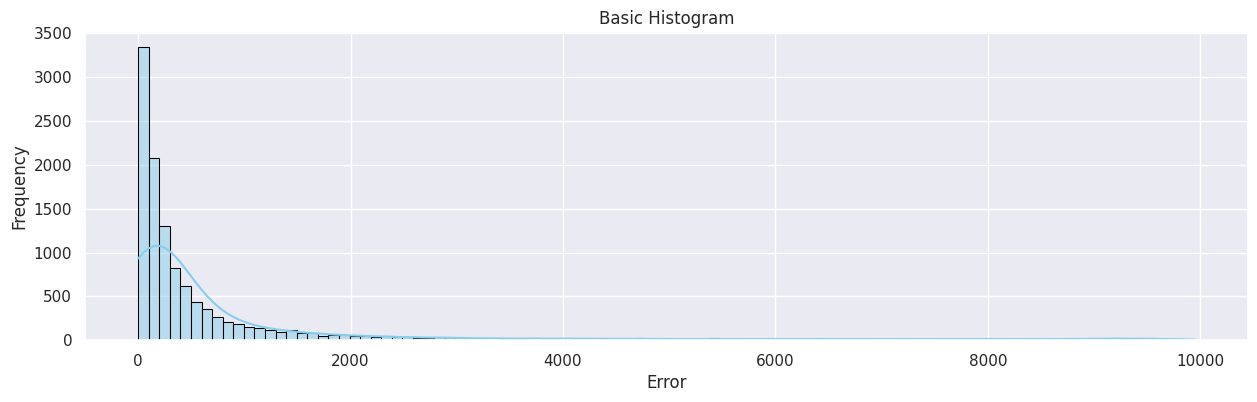

In [16]:
# Generate Abs of Error data for the histogram
abs_erorr = np.abs(y_test1-preds)
 
# Plotting a histogram
plt.figure(figsize=(15, 4))
sns.histplot(abs_erorr, bins=100, kde=True, color='skyblue', edgecolor='black')
 
# Adding labels and title
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Basic Histogram')
 
# Display the plot
plt.show()

## Histogram on the Mean of Error

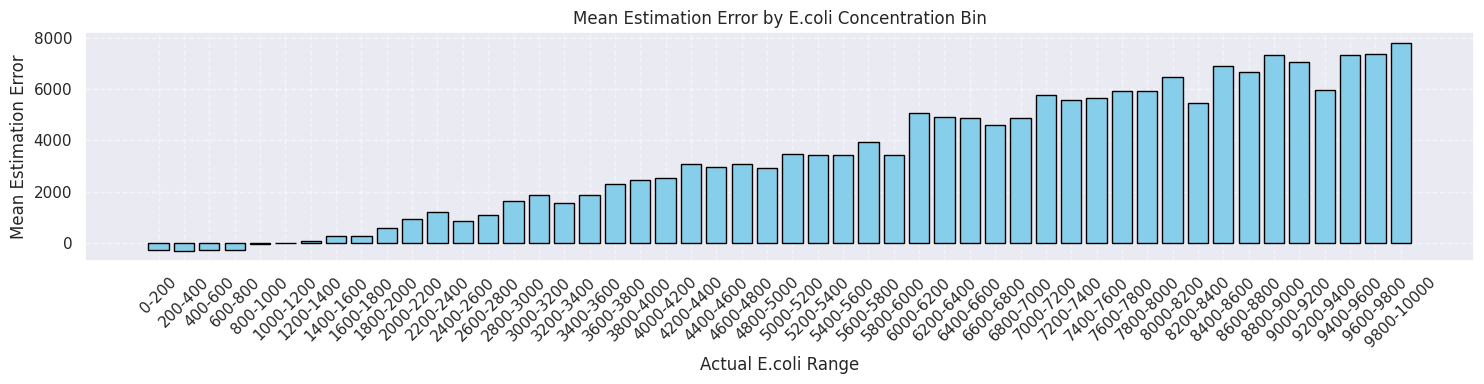

In [17]:
# Define signal strength bins 
bins = np.arange(0, 10200, 200)  

erorr = y_test1-preds
 

# Digitize signal strength into bin indices
bin_indices = np.digitize(y_test1, bins)

# Compute mean error for each bin
mean_errors = []
bin_labels = []

for i in range(1, len(bins)):
    in_bin = bin_indices == i
    if np.any(in_bin):
        mean_error = np.mean(erorr[in_bin])
        mean_errors.append(mean_error)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")
    else:
        mean_errors.append(0)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")

# Plotting
plt.figure(figsize=(15, 4))
plt.bar(bin_labels, mean_errors, color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Actual E.coli Range')
plt.ylabel('Mean Estimation Error')
plt.title('Mean Estimation Error by E.coli Concentration Bin')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Histogram on the Abd. Mean of Error

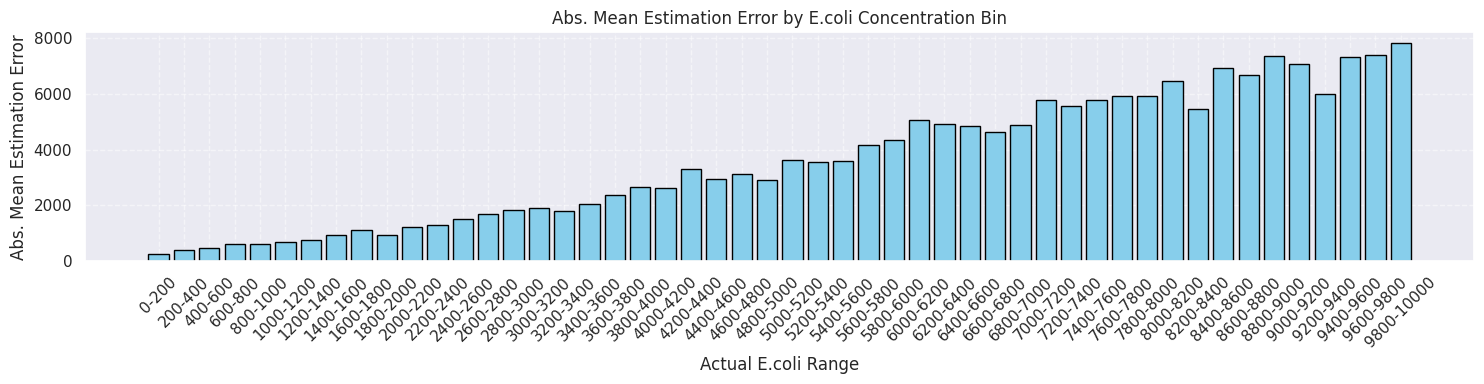

In [18]:
# Define signal strength bins 
bins = np.arange(0, 10200, 200)  

# Digitize signal strength into bin indices
bin_indices = np.digitize(y_test1, bins)

# Compute mean error for each bin
mean_errors = []
bin_labels = []

for i in range(1, len(bins)):
    in_bin = bin_indices == i
    if np.any(in_bin):
        mean_error = np.mean(abs_erorr[in_bin])
        mean_errors.append(mean_error)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")
    else:
        mean_errors.append(0)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")

# Plotting
plt.figure(figsize=(15, 4))
plt.bar(bin_labels, mean_errors, color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Actual E.coli Range')
plt.ylabel('Abs. Mean Estimation Error')
plt.title('Abs. Mean Estimation Error by E.coli Concentration Bin')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Generate the distribution data in histogram format

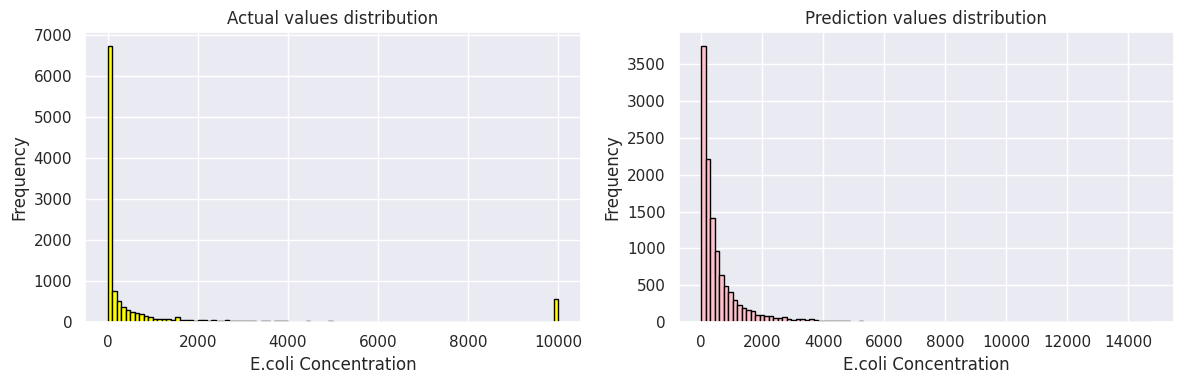

In [19]:
# Generate the distribution data in histogram format
pre = preds

# Plotting a histogram
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
 
axes[0].hist(y_test1, bins=100, color='Yellow', edgecolor='black')
axes[0].set_title('Actual values distribution')
 
axes[1].hist(pre, bins=100, color='Pink', edgecolor='black')
axes[1].set_title('Prediction values distribution')
 
# Adding labels and title
for ax in axes:
    ax.set_xlabel('E.coli Concentration')
    ax.set_ylabel('Frequency')
    
# Adjusting layout for better spacing
plt.tight_layout()
 
# Display the figure
plt.show()

# Precision-Recall and ROC curves 

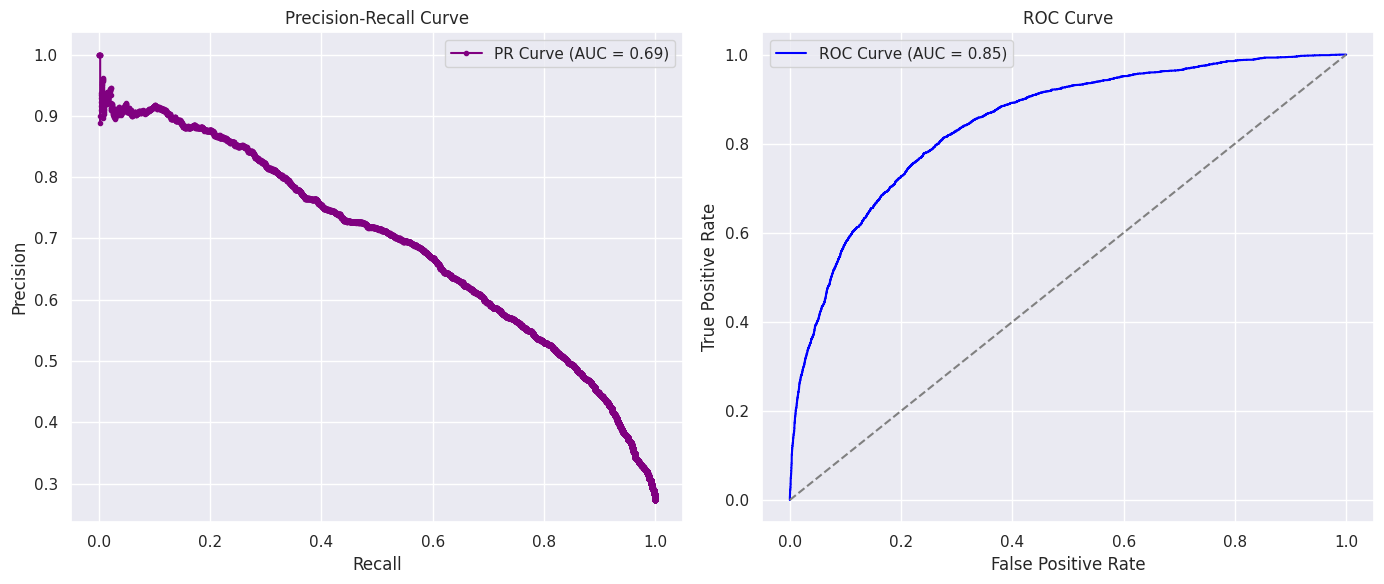

In [30]:
# Define a threshold to create binary classification labels
# y_true > 1000 as the positive class for E.coli
binary_true = (y_test > 1000).astype(int)

Scaler1 = joblib.load("Model/Scaler1_Tmp_lgt.save")

# Precision-Recall Curve
precision_xgr, recall_xgr, pr_thresholds_xgr = precision_recall_curve(binary_true, preds.values)
pr_auc_xgr = auc(recall_xgr, precision_xgr)

# ROC Curve
fpr_xgr, tpr_xgr, roc_thresholds_xgr = roc_curve(binary_true, Scaler1.inverse_transform(preds.values.reshape(-1, 1)).reshape(-1))
roc_auc_xgr = auc(fpr_xgr, tpr_xgr)

# 4. Plotting
plt.figure(figsize=(14, 6))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall_xgr, precision_xgr, label=f'PR Curve (AUC = {pr_auc_xgr:.2f})', marker='.', color='purple')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr_xgr, tpr_xgr, color='blue', label=f'ROC Curve (AUC = {roc_auc_xgr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Other acuuracy metrics

three other Accuracy metrics. 

In [29]:
tst = y_test.to_numpy().copy()
pre = preds.values.reshape(-1).copy()
tst[tst<10] = 10
tst[tst>10000] = 10000
pre[pre<10] = 10
pre[pre>10000] = 10000

# Accuracy = (1 - sMAPE) * 100
print("Accuracy = (1 - sMAPE) * 100 = %.5f" % (( np.mean(np.abs(tst - pre) / ((np.abs(tst)+np.abs(pre))/2))) * 100),"%")

# Percentage of estimations within a certain error margin.
# Accuracy = (number of estimations with error < thr)/ all samples
thr = 0.4
tst = np.log10(tst)
pre = np.log10(pre)
error = (np.abs(pre - tst))
print("Accuracy = number of estimations with error < 0.4)/ all samples = %.5f" % ((error < thr).sum()/len(error)*100),"%")

# threshold based accuracy. precentage of estimation with error < thr of actual value
thr = 0.05
error = np.abs(pre - tst) < 0.2 * tst
print("Accuracy = precentage of estimation with error < 20 percent of actual value = %.5f" % (error.sum()/len(tst)*100),"%")

Accuracy = (1 - sMAPE) * 100 = 121.73803 %
Accuracy = number of estimations with error < 0.4)/ all samples = 28.68101 %
Accuracy = precentage of estimation with error < 20 percent of actual value = 34.89245 %


# E.coli Classifiers

Unlike the estimators, this section focuses on classification tasks, predicting whether E.coli levels exceed a certain threshold (e.g., high vs. low levels).

In [32]:
# Run this cell only if Temporal Split 
y_test = datasetxxt['Ecoli']
thr = 1000
y_test = y_test.astype(float).apply(lambda x: (0 if (x <thr)
                                     else 1))

In [99]:
# Run this cell only if Geographical Split 
y_test2 = y_test.copy()

In [110]:
# Run this cell only if Geographical Split 
thr = 500 # change thr and run fron this cell onward
y_test = pd.DataFrame({'Ecoli': y_test2}).astype(float).apply(lambda x: [0 if y < thr else 1 for y in x])

## XGBClassifier

This applies XGBoost for classification, effectively handling complex patterns in E. coli presence.

Accuracy: 0.7970
F1 Score: 0.7754
Recall: 0.7970
Precision: 0.7890
False Positives (FP): 0.038936134734033685
False Negatives (FN): 0.16408204102051024


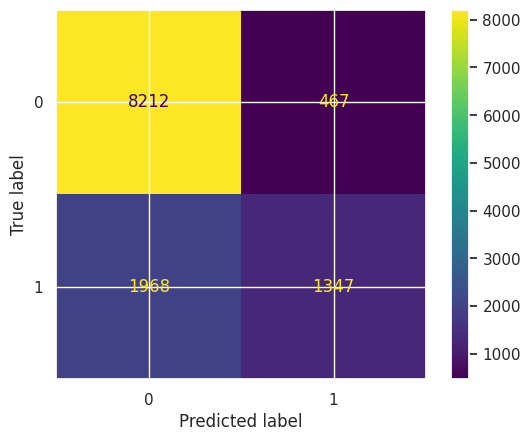

In [112]:
from sklearn.metrics import f1_score,recall_score,precision_score
#load model
# Choose between xgbc_f{fold}_Tmp_lgt_{thr}.joblib and xgbc_f{fold}_Geo_lgt_{thr}.joblib depending on model trained approach
trained_models = [joblib.load(f'Model/xgbc_f{fold}_Geo_lgt_{thr}.joblib') for fold in range(10)]

y_pred = []
for model in trained_models:
    y_pred.append(pd.Series(data=model.predict(X_testN), dtype='float64'))
y_pred = pd.concat(y_pred, axis=1)
y_pred = y_pred.mean(axis=1).round()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
   
# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fp_percent = fp/(tn+fp+fn+tp)
fn_percent = fn/(tn+fp+fn+tp)

# Display Results
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"False Positives (FP): {fp_percent}")
print(f"False Negatives (FN): {fn_percent}")

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

## Map on Geographical Distribution of Classification Performance

This final step visualizes the model’s accuracy across different geographical locations, helping to identify spatial trends in E.coli classification accuracy.

In [109]:
# Run this cell only for Temporal split 
XX = datasetxxt.drop(['E.coli C-MF','date'], axis=1)
XX_train, XX_test, yy_train, yy_test = train_test_split(XX, y, test_size=0.15, random_state=42)

In [28]:
# On result["result"]: zero means correct classification and one means worng classification

#result = pd.concat([y_test, XX_test[["Lat","Long"]]], axis=1) # for Temporal split keep this line
result = pd.concat([y_test, datasetxxt[["Lat","Long"]]], axis=1) # for Geographical split keep this line
result["result"] = (result["E.coli C-MF"] ^ y_pred.astype(int))
result.head()

,E.coli C-MF,Lat,Long,result
0,1,52.188607,1.451225,0
1,0,52.188607,1.451225,0
2,0,52.188607,1.451225,0
3,1,52.188607,1.451225,1
4,0,52.188607,1.451225,0


In [30]:
# map show locations green >75%, 75%> yellow >65%, 65%> orange >55% and 55%> red of accuracy on classification
# with 4 different size of counts
import folium
import pandas as pd
import branca.colormap as cm
from scipy import stats
from utils import getradius2

grouped_data = result[['result','Long','Lat']]
grouped_data = grouped_data.dropna().reset_index(drop=True)
grouped_data = grouped_data.groupby(["Lat", "Long"]).agg(
    ecoli_mean = ("result","mean"),
    ecoli_count = ("result","count")
).reset_index()

# Sample data generation (Replace this with your actual DataFrame)
df = grouped_data
df = df[df['Lat'] > 49.90] #Drop unwanted rows
df = df[df['Lat'] < 61] #Drop unwanted rows


m = folium.Map(location=[df['Lat'].median(), df['Long'].median()], zoom_start=5)

# green >75%, 75%> yellow >65%, 65%> orange >55% and 55%> red 
colormap = cm.LinearColormap(colors=['green', 'yellow', 'orange', 'red'], vmin=0.2, vmax=0.5)

# Add circle markers for each location
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius= getradius2(row['ecoli_count']),  # Scale the radius according to the counts
        color=colormap(row['ecoli_mean']),  # Assign color based on intensity
        fill=True,
        fill_opacity=0.6,
        popup=f"Intensity: {row['ecoli_mean']}"
    ).add_to(m)

# Save map to an HTML file
m.save('ecoli_t_val.html')

m